<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB
gender
male      61

C:\Users\himan\AppData\Local\Temp\ipykernel_24160\3720632518.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


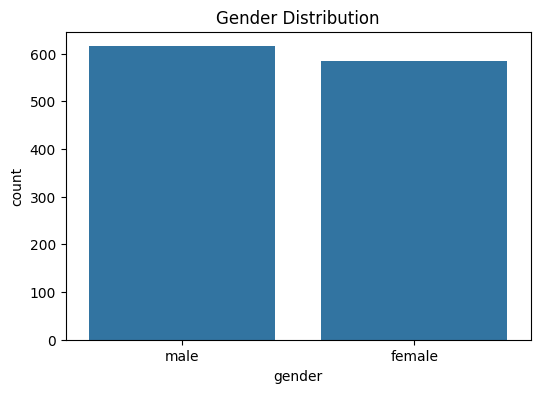

platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64


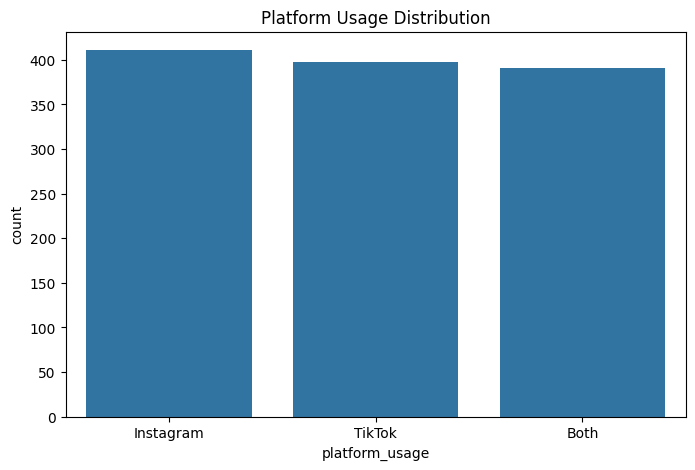

Average Social Media Usage Hours:
4.536666666666667
Average Sleep Hours:
6.449416666666667


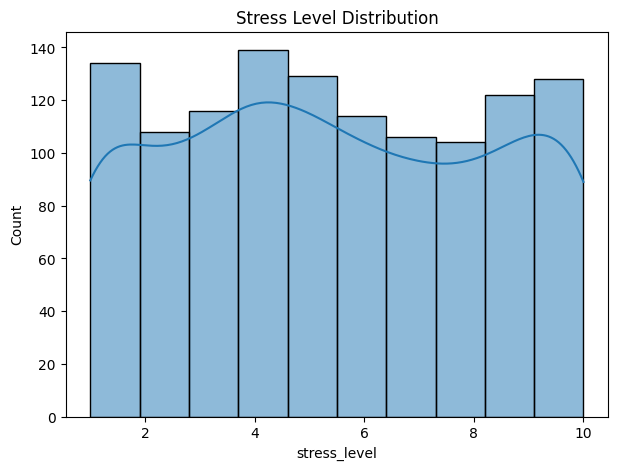

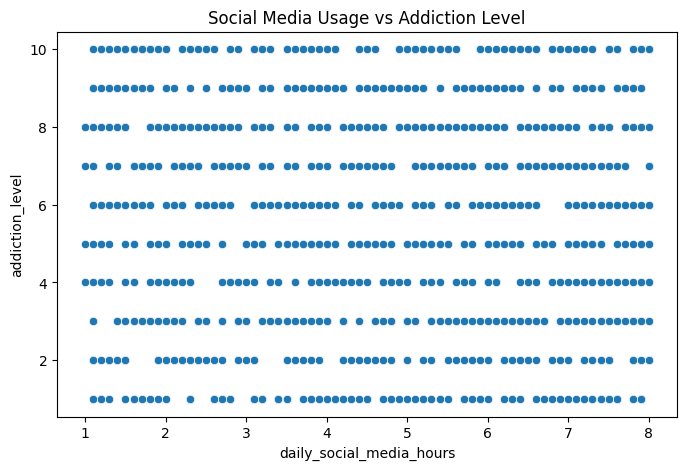

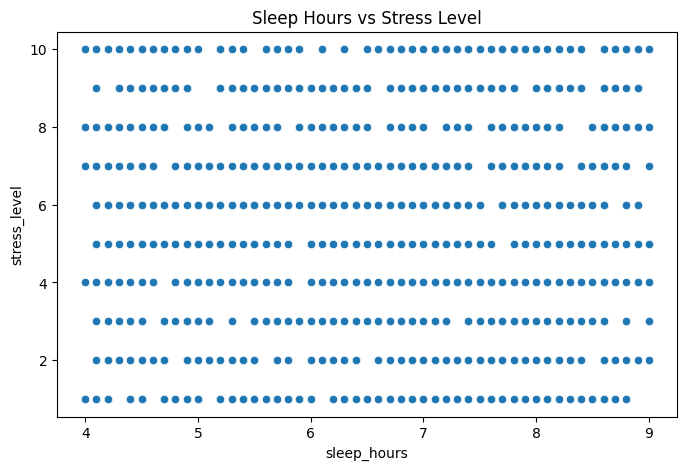

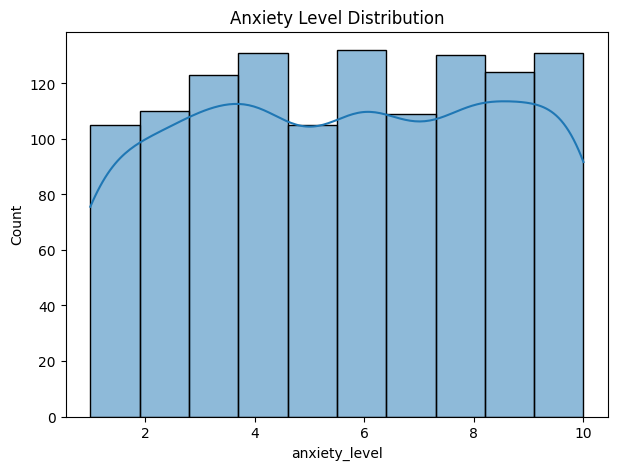

Depression Cases:
depression_label
0    1169
1      31
Name: count, dtype: int64


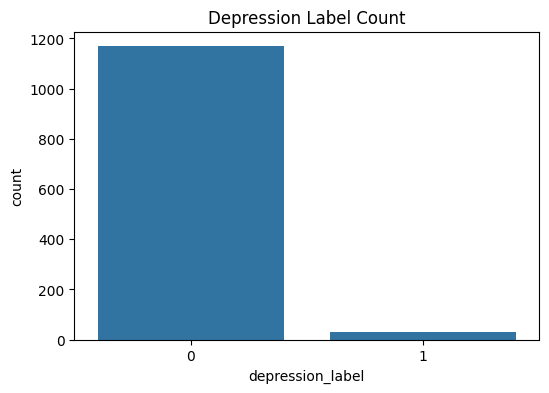

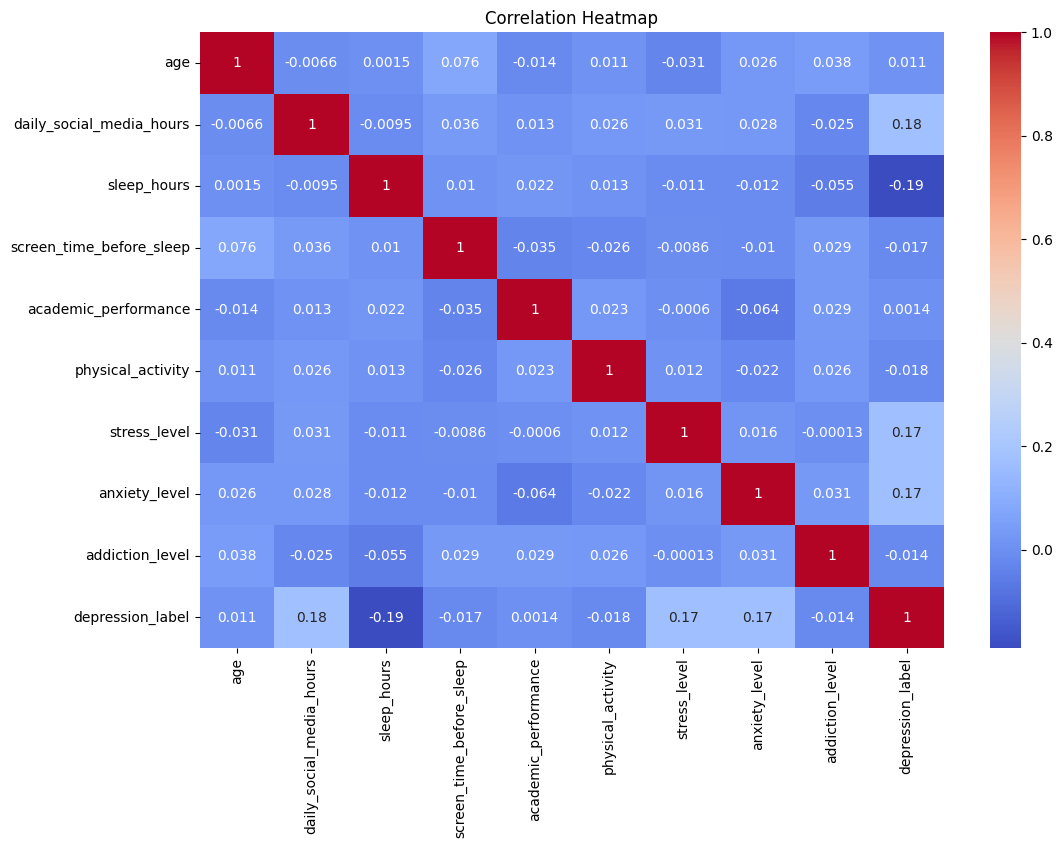

Project Completed Successfully
Key Insights:
1. More social media usage leads to higher addiction
2. Less sleep increases stress and anxiety
3. Physical activity improves mental health
4. Depression cases are linked with high addiction and low sleep


In [3]:
# Teen Mental Health Dataset Analysis Project
# Jupyter Notebook Code

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load CSV File
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

# Step 3: View First 5 Rows
df.head()

# Step 4: Basic Information
df.info()

# Step 5: Check Missing Values
df.isnull().sum()

# Step 6: Check Duplicate Rows
df.duplicated().sum()

# Step 7: Remove Duplicates (if any)
df = df.drop_duplicates()

# Step 8: Clean Text Columns (remove extra spaces)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# Step 9: Statistical Summary
df.describe()

# Step 10: Gender Distribution
print(df['gender'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

# Step 11: Platform Usage Distribution
print(df['platform_usage'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x='platform_usage', data=df)
plt.title("Platform Usage Distribution")
plt.show()

# Step 12: Average Social Media Usage Hours
print("Average Social Media Usage Hours:")
print(df['daily_social_media_hours'].mean())

# Step 13: Average Sleep Hours
print("Average Sleep Hours:")
print(df['sleep_hours'].mean())

# Step 14: Stress Level Analysis
plt.figure(figsize=(7,5))
sns.histplot(df['stress_level'], bins=10, kde=True)
plt.title("Stress Level Distribution")
plt.show()

# Step 15: Social Media Usage vs Addiction Level
plt.figure(figsize=(8,5))
sns.scatterplot(x='daily_social_media_hours', y='addiction_level', data=df)
plt.title("Social Media Usage vs Addiction Level")
plt.show()

# Step 16: Sleep Hours vs Stress Level
plt.figure(figsize=(8,5))
sns.scatterplot(x='sleep_hours', y='stress_level', data=df)
plt.title("Sleep Hours vs Stress Level")
plt.show()

# Step 17: Anxiety Level Distribution
plt.figure(figsize=(7,5))
sns.histplot(df['anxiety_level'], bins=10, kde=True)
plt.title("Anxiety Level Distribution")
plt.show()

# Step 18: Depression Count
print("Depression Cases:")
print(df['depression_label'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='depression_label', data=df)
plt.title("Depression Label Count")
plt.show()

# Step 19: Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Step 20: Final Insights
print("Project Completed Successfully")
print("Key Insights:")
print("1. More social media usage leads to higher addiction")
print("2. Less sleep increases stress and anxiety")
print("3. Physical activity improves mental health")
print("4. Depression cases are linked with high addiction and low sleep")

In [7]:
# Teen Mental Health Dataset - ML Model Prediction (Revised Full Code)

# Step 1: Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 2: Load Dataset
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

# Step 3: Clean Text Columns (remove spaces + lowercase)
for col in ['gender', 'platform_usage', 'social_interaction_level']:
    df[col] = df[col].str.strip().str.lower()

# Step 4: Check Unique Values (optional)
print("Platform Usage Values:")
print(df['platform_usage'].unique())

print("\nGender Values:")
print(df['gender'].unique())

print("\nSocial Interaction Values:")
print(df['social_interaction_level'].unique())

# Step 5: Encode Categorical Columns
le_gender = LabelEncoder()
le_platform = LabelEncoder()
le_social = LabelEncoder()

df['gender'] = le_gender.fit_transform(df['gender'])
df['platform_usage'] = le_platform.fit_transform(df['platform_usage'])
df['social_interaction_level'] = le_social.fit_transform(df['social_interaction_level'])

# Step 6: Define Features (X) and Target (y)
X = df.drop('depression_label', axis=1)
y = df['depression_label']

# Step 7: Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Step 8: Build Model
model = RandomForestClassifier(random_state=42)

# Step 9: Train Model
model.fit(X_train, y_train)

# Step 10: Prediction on Test Data
y_pred = model.predict(X_test)

# Step 11: Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)

# Step 12: Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 13: Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Step 14: Single Student Prediction Example
sample_data = pd.DataFrame({
    'age': [16],
    'gender': [le_gender.transform(['male'])[0]],
    'daily_social_media_hours': [7.5],
    'platform_usage': [le_platform.transform(['instagram'])[0]],
    'sleep_hours': [5.0],
    'screen_time_before_sleep': [2.5],
    'academic_performance': [2.4],
    'physical_activity': [1.0],
    'social_interaction_level': [le_social.transform(['low'])[0]],
    'stress_level': [8],
    'anxiety_level': [9],
    'addiction_level': [8]
})

# Step 15: Final Prediction
prediction = model.predict(sample_data)

if prediction[0] == 1:
    print("\nPrediction Result: Depression Risk = YES")
else:
    print("\nPrediction Result: Depression Risk = NO")

Platform Usage Values:
<StringArray>
['instagram', 'tiktok', 'both']
Length: 3, dtype: str

Gender Values:
<StringArray>
['male', 'female']
Length: 2, dtype: str

Social Interaction Values:
<StringArray>
['low', 'high', 'medium']
Length: 3, dtype: str

Model Accuracy: 0.9791666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       234
           1       1.00      0.17      0.29         6

    accuracy                           0.98       240
   macro avg       0.99      0.58      0.64       240
weighted avg       0.98      0.98      0.97       240


Confusion Matrix:
[[234   0]
 [  5   1]]

Prediction Result: Depression Risk = NO
